# Four Qubit Chip Design

In [1]:
%reload_ext autoreload
%autoreload 2

## Prerequisite

In [2]:
import numpy as np
from collections import OrderedDict

from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, Headings

from qiskit_metal.qlibrary.qubits.transmon_pocket_cl import TransmonPocketCL
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.anchored_path import RouteAnchors
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.terminations.launchpad_wb_coupled import LaunchpadWirebondCoupled

## Create the Four Qbit Design

In [3]:
design = designs.DesignPlanar()

gui = MetalGUI(design)

In [4]:
design.overwrite_enabled = True

In [5]:
design.variables['cpw_width'] = '10 um'
design.variables['cpw_gap'] = '6 um'
design._chips['main']['size']['size_y'] = '9mm'
design._chips['main']['size']['size_y'] = '6.5mm'

We need 4 transmons with 3 connection pads each and a chargeline. Let's explore the options of one transmon

In [6]:
TransmonPocketCL.get_template_options(design)

{'pos_x': '0.0um',
 'pos_y': '0.0um',
 'orientation': '0.0',
 'chip': 'main',
 'layer': '1',
 'connection_pads': {},
 '_default_connection_pads': {'pad_gap': '15um',
  'pad_width': '125um',
  'pad_height': '30um',
  'pad_cpw_shift': '5um',
  'pad_cpw_extent': '25um',
  'cpw_width': 'cpw_width',
  'cpw_gap': 'cpw_gap',
  'cpw_extend': '100um',
  'pocket_extent': '5um',
  'pocket_rise': '65um',
  'loc_W': '+1',
  'loc_H': '+1'},
 'pad_gap': '30um',
 'inductor_width': '20um',
 'pad_width': '455um',
 'pad_height': '90um',
 'pocket_width': '650um',
 'pocket_height': '650um',
 'make_CL': True,
 'cl_gap': '6um',
 'cl_width': '10um',
 'cl_length': '20um',
 'cl_ground_gap': '6um',
 'cl_pocket_edge': '0',
 'cl_off_center': '50um',
 'hfss_wire_bonds': False,
 'q3d_wire_bonds': False,
 'aedt_q3d_wire_bonds': False,
 'aedt_hfss_wire_bonds': False,
 'hfss_inductance': '10nH',
 'hfss_capacitance': 0,
 'hfss_resistance': 0,
 'hfss_mesh_kw_jj': 7e-06,
 'q3d_inductance': '10nH',
 'q3d_capacitance': 0,
 

We want to change the `pad_width` for these transmons, as well as define the 3 connection pads and chargeline.

To apply the same modifications to all 4 transmons, we define a single option-dictionary to pass to all transmons at the monent of creation

In [7]:
transmon_options = dict(
    connection_pads=dict(
        a = dict(loc_W=+1, loc_H=-1, pad_width='70um', cpw_extend = '50um'), 
        b = dict(loc_W=-1, loc_H=-1, pad_width='125um', cpw_extend = '50um'),
        c = dict(loc_W=-1, loc_H=+1, pad_width='110um', cpw_extend = '50um')
    ),
    gds_cell_name='FakeJunction_01',
    cl_off_center = '-50um',
    cl_pocket_edge = '180',
    pad_gap = '30um', # 30 um, 50 um, 80 um, 110 um
    inductor_width = '20um' # 20 um, 10 um, 15 um, 20 um
)

We can now create the 4 transmons by specifying the desired coordinates and orientations.

In [8]:
offset_tm = 69  #we the transmon slightly out of center-line

q1 = TransmonPocketCL(design, 'Q1', options = dict(
     pos_x='+2420um', pos_y=f'428.5um', **transmon_options))
    # pos_x='+2420um', pos_y=f'{offset_tm}um', **transmon_options))
q2 = TransmonPocketCL(design, 'Q2', options = dict(
    pos_x='428.5um', pos_y='-857.6um', orientation = '270', **transmon_options))
q3 = TransmonPocketCL(design, 'Q3', options = dict(
    pos_x='-2420um', pos_y=f'-428.5um', orientation = '180', **transmon_options))
    # pos_x='-2420um', pos_y=f'{offset_tm}um', orientation = '180', **transmon_options))
q4 = TransmonPocketCL(design, 'Q4', options = dict(
    pos_x='-428.5um', pos_y='+857.6um', orientation = '90', **transmon_options))

gui.rebuild()
gui.autoscale()

Let's now connect the transmons with tranismission lines. We want to have an "exact length" transmission line, so we will use the `RouteMeander`. Let's first observe what are the default options

In [9]:
RouteMeander.get_template_options(design)

{'chip': 'main',
 'layer': '1',
 'pin_inputs': {'start_pin': {'component': '', 'pin': ''},
  'end_pin': {'component': '', 'pin': ''}},
 'fillet': '0',
 'lead': {'start_straight': '0mm',
  'end_straight': '0mm',
  'start_jogged_extension': '',
  'end_jogged_extension': ''},
 'total_length': '7mm',
 'trace_width': 'cpw_width',
 'meander': {'spacing': '200um', 'asymmetry': '0um'},
 'snap': 'true',
 'prevent_short_edges': 'true',
 'hfss_wire_bonds': False,
 'q3d_wire_bonds': False,
 'aedt_q3d_wire_bonds': False,
 'aedt_hfss_wire_bonds': False}

We want to globally override the default lead (straight initial segment leaving the transmon) and the default fillet (corner rounding radius). Let's collect this information in one dictionary

In [10]:
fillet='99.99um'
cpw_options = Dict(
    lead=Dict(
        start_straight='100um',
        end_straight='150um'),
        # end_straight='250um'),
    fillet=fillet
    )

We then want each transmission line to be connected to different pins and to have different lengths and asymmetry w.r.t their centerline. Let's collect this information in other dictionaries. Before doing that, to manage the dictionaries in a simpler way, we redefine the `RouteMeander` signature by wrapping it into a convenience method named `connect`

In [11]:
def connect(cpw_name: str, pin1_comp_name: str, pin1_comp_pin: str, pin2_comp_name: str, pin2_comp_pin: str,
            length: str, asymmetry='0 um'):
    """Connect two pins with a CPW."""
    myoptions = Dict(
        pin_inputs=Dict(
            start_pin=Dict(
                component=pin1_comp_name,
                pin=pin1_comp_pin),
            end_pin=Dict(
                component=pin2_comp_name,
                pin=pin2_comp_pin)),
        total_length=length)
    myoptions.update(cpw_options)
    myoptions.meander.asymmetry = asymmetry
    return RouteMeander(design, cpw_name, myoptions)

We can now proceed and define the meanders following the signature: `connect(cpw_name, pin1_comp_name, pin1_comp_pin, pin2_comp_name, pin2_comp_pin, length, asymmetry)`

In [12]:
asym = 500
cpw1 = connect('cpw1', 'Q1', 'c', 'Q4', 'b', '9000um', f'-{asym-1.25*offset_tm}um')
cpw2 = connect('cpw2', 'Q3', 'b', 'Q4', 'c', '9000um', f'+{asym-1.25*offset_tm}um')
cpw3 = connect('cpw3', 'Q3', 'c', 'Q2', 'b', '9000um', f'-{asym+0.75*offset_tm}um')
cpw4 = connect('cpw4', 'Q1', 'b', 'Q2', 'c', '9000um', f'+{asym+0.75*offset_tm}um')

gui.rebuild()
gui.autoscale()

### Let's now connect the core elements to the launchpads

First we setup the launchpad location and orientation

In [13]:
# V1 - Corners
p1_c = LaunchpadWirebond(design, 'P1_C', options = dict(pos_x='3545um', pos_y='2812um', orientation='270', lead_length='0um'))
p2_c = LaunchpadWirebond(design, 'P2_C', options = dict(pos_x='3545um', pos_y='-2812um', orientation='90', lead_length='0um'))
p3_c = LaunchpadWirebond(design, 'P3_C', options = dict(pos_x='-3545um', pos_y='-2812um', orientation='90', lead_length='0um'))
p4_c = LaunchpadWirebond(design, 'P4_C', options = dict(pos_x='-3545um', pos_y='2812um', orientation='270', lead_length='0um'))

# V2
p1_q = LaunchpadWirebondCoupled(design, 'P1_Q', options = dict(pos_x='4020um', pos_y='0', orientation='180', lead_length='30um'))
p2_q = LaunchpadWirebondCoupled(design, 'P2_Q', options = dict(pos_x='-990um', pos_y='-2812um', orientation='90', lead_length='30um'))
p3_q = LaunchpadWirebondCoupled(design, 'P3_Q', options = dict(pos_x='-4020um', pos_y='0', orientation='0', lead_length='30um'))
p4_q = LaunchpadWirebondCoupled(design, 'P4_Q', options = dict(pos_x='990um', pos_y='2812um', orientation='270', lead_length='30um'))

gui.rebuild()
gui.autoscale()

Then we route. First the V2 launchpads - Exchange Coupler Lines to Edges

In [14]:
asym = 150
cpw_options = Dict(
    lead=Dict(
        start_straight='430um',
        end_straight='0um'),
    fillet=fillet
    )
ol1 = connect('ol1', 'Q1', 'a', 'P1_Q', 'tie', '8.6 mm', f'+{asym}um')
ol3 = connect('ol3', 'Q3', 'a', 'P3_Q', 'tie', '8.6 mm', f'+{asym}um')

asym = 200
cpw_options = Dict(
    lead=Dict(
        start_straight='535um',
        end_straight='0um'),
    fillet=fillet
    )
# ol2 = connect('ol2', 'Q2', 'a', 'P2_Q', 'tie', '8.6 mm', f'+{asym}um')
ol2 = connect('ol2', 'Q2', 'a', 'P2_Q', 'tie', '5 mm', f'+{asym}um')
ol4 = connect('ol4', 'Q4', 'a', 'P4_Q', 'tie', '8.6 mm', f'+{asym}um')

gui.rebuild()
gui.autoscale()

Finally we route the V1 launchpads - Charge Lines to Corners

We create the transmission lines between the corner launchpads and the open to grounds

In [15]:
from collections import OrderedDict
jogsA_in = OrderedDict()
jogsA_in[0] = ["L", '200um']

options_line_cl1 = {'pin_inputs': 
            {'start_pin': {'component': 'Q1', 'pin': 'Charge_Line'}, 
             'end_pin': {'component': 'P1_C', 'pin': 'tie'}},
            'lead': {'start_straight': '120um', 'end_straight': '225um','start_jogged_extension': jogsA_in},
            'fillet': fillet
            }
cl1 = RouteAnchors(design, 'line_cl1', options_line_cl1)

options_line_cl3 = {'pin_inputs': 
            {'start_pin': {'component': 'Q3', 'pin': 'Charge_Line'}, 
             'end_pin': {'component': 'P3_C', 'pin': 'tie'}},
            'lead': {'start_straight': '120um', 'end_straight': '225um', 'start_jogged_extension': jogsA_in},
            'fillet': fillet
            }
cl3 = RouteAnchors(design, 'line_cl3', options_line_cl3)

gui.rebuild()
gui.autoscale()

In [16]:
jogsB_in = OrderedDict()
jogsB_in[0] = ["L", '300um']

anchors2c = OrderedDict()
anchors2c[0] = np.array([2, -2.5])

options_line_cl2 = {'pin_inputs': 
            {'start_pin': {'component': 'Q2', 'pin': 'Charge_Line'}, 
             'end_pin': {'component': 'P2_C', 'pin': 'tie'}},
            'lead': {'start_straight': '200um', 'end_straight': '225um',
                     'start_jogged_extension': jogsB_in},
            'anchors': anchors2c,
            'fillet': fillet
            }

cl2 = RouteAnchors(design, 'line_cl2', options_line_cl2)

anchors4c = OrderedDict()
anchors4c[0] = np.array([-2, 2.5])

options_line_cl4 = {'pin_inputs': 
            {'start_pin': {'component': 'Q4', 'pin': 'Charge_Line'}, 
             'end_pin': {'component': 'P4_C', 'pin': 'tie'}},
            'lead': {'start_straight': '200um', 'end_straight': '225um',
                     'start_jogged_extension': jogsB_in},
            'anchors': anchors4c,
            'fillet': fillet
            }

cl4 = RouteAnchors(design, 'line_cl4', options_line_cl4)

gui.rebuild()
gui.autoscale()

In [17]:
gui.rebuild()  # rebuild the design and plot 
gui.autoscale() #resize GUI to see QComponent

In [18]:
# Get a list of all the qcomponents in QDesign and then zoom on them.
all_component_names = design.components.keys()

gui.zoom_on_components(all_component_names)

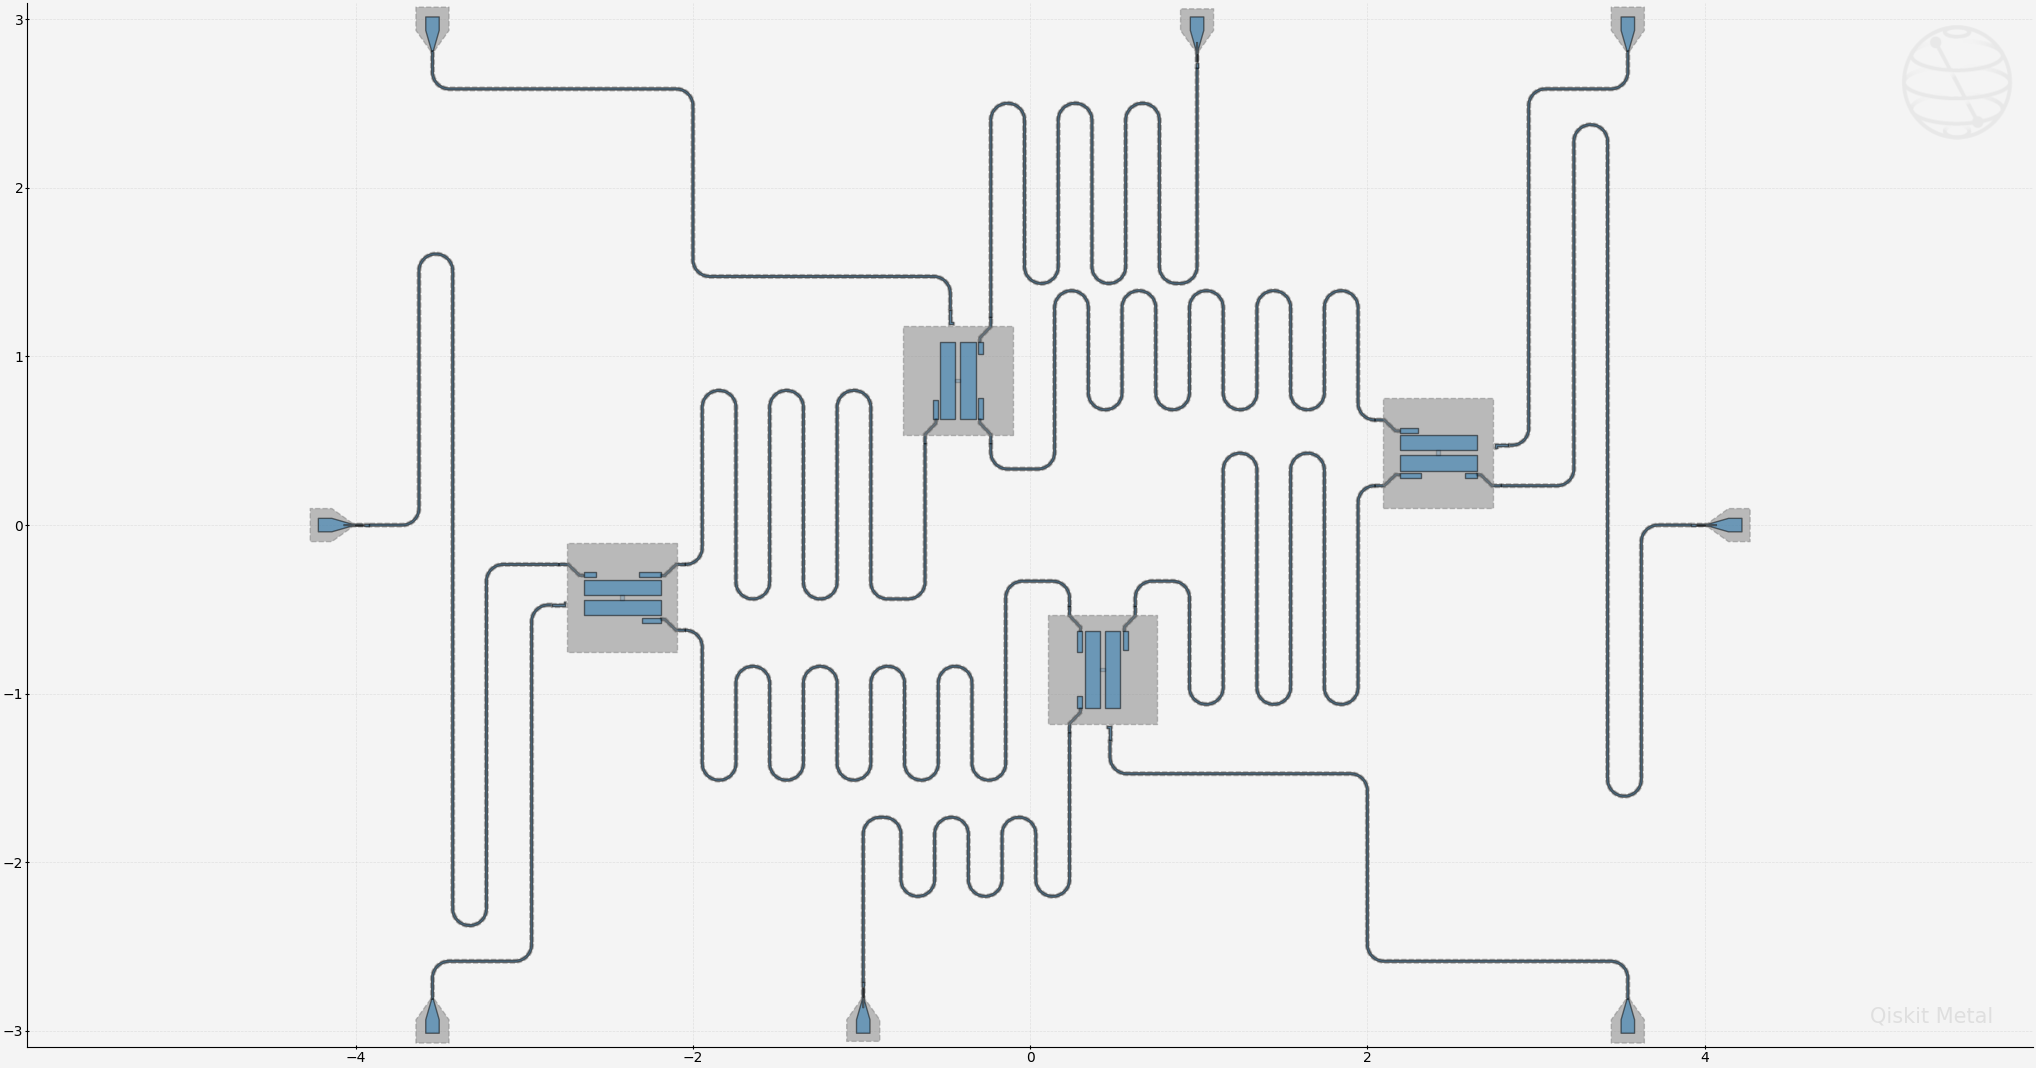

In [19]:
# Screenshot the canvas only as a .png formatted file.
# gui.screenshot()
gui.figure.savefig('shot.png')

from IPython.display import Image, display
_disp_ops = dict(width=500)
display(Image('shot.png', **_disp_ops))

In [ ]:
# # Closing the Qiskit Metal GUI
# gui.main_window.close()

## Analyze the chip using the Eigenmode method and EPR analysis

### Eigenmode

In [20]:
design.qgeometry.tables['junction']

,component,name,geometry,layer,subtract,helper,chip,width,hfss_inductance,hfss_capacitance,...,hfss_mesh_kw_jj,q3d_inductance,q3d_capacitance,q3d_resistance,q3d_mesh_kw_jj,gds_cell_name,aedt_q3d_inductance,aedt_q3d_capacitance,aedt_hfss_inductance,aedt_hfss_capacitance
0,1,rect_jj,"LINESTRING (2.42000 0.41350, 2.42000 0.44350)",1,False,False,main,0.02,10nH,0,...,0.000007,10nH,0,0,0.000007,FakeJunction_01,1.000000e-08,0,1.000000e-08,0
1,2,rect_jj,"LINESTRING (0.41350 -0.85760, 0.44350 -0.85760)",1,False,False,main,0.02,10nH,0,...,0.000007,10nH,0,0,0.000007,FakeJunction_01,1.000000e-08,0,1.000000e-08,0
2,3,rect_jj,"LINESTRING (-2.42000 -0.41350, -2.42000 -0.44350)",1,False,False,main,0.02,10nH,0,...,0.000007,10nH,0,0,0.000007,FakeJunction_01,1.000000e-08,0,1.000000e-08,0
3,4,rect_jj,"LINESTRING (-0.41350 0.85760, -0.44350 0.85760)",1,False,False,main,0.02,10nH,0,...,0.000007,10nH,0,0,0.000007,FakeJunction_01,1.000000e-08,0,1.000000e-08,0


In [21]:
qcomps = design.components

qcomps['Q1'].options['hfss_inductance'] = 'Lj1'
qcomps['Q1'].options['hfss_capacitance'] = 'Cj1'
qcomps['Q2'].options['hfss_inductance'] = 'Lj2'
qcomps['Q2'].options['hfss_capacitance'] = 'Cj2'
qcomps['Q3'].options['hfss_inductance'] = 'Lj3'
qcomps['Q3'].options['hfss_capacitance'] = 'Cj3'
qcomps['Q4'].options['hfss_inductance'] = 'Lj4'
qcomps['Q4'].options['hfss_capacitance'] = 'Cj4'

gui.rebuild()
gui.autoscale()

In [22]:
from qiskit_metal.analyses.quantization import EPRanalysis
eig_4qb = EPRanalysis(design, "hfss")

In [ ]:
eig_4qb.sim.setup.max_passes = 10
eig_4qb.sim.setup.max_delta_f = 0.05
eig_4qb.sim.setup.n_modes = 4
eig_4qb.sim.setup.convergence_accuracy="high"
eig_4qb.sim.setup.vars = Dict(Lj1= '13 nH', Cj1= '0 fF', # xwritikothta kai empedish
                           Lj2= '9 nH', Cj2= '0 fF',
                           Lj3= '13 nH', Cj3= '0 fF',
                           Lj4= '9 nH', Cj4= '0 fF')
eig_4qb.sim.setup

{'name': 'Setup',
 'reuse_selected_design': True,
 'reuse_setup': True,
 'min_freq_ghz': 1,
 'n_modes': 4,
 'max_delta_f': 0.05,
 'max_passes': 10,
 'min_passes': 1,
 'min_converged': 1,
 'pct_refinement': 30,
 'basis_order': 1,
 'vars': {'Lj1': '13 nH',
  'Cj1': '0 fF',
  'Lj2': '9 nH',
  'Cj2': '0 fF',
  'Lj3': '13 nH',
  'Cj3': '0 fF',
  'Lj4': '9 nH',
  'Cj4': '0 fF'},
 'convergence_accuracy': 'high'}

In [24]:
eig_4qb.sim.renderer.options['x_buffer_width_mm'] = 0.5
eig_4qb.sim.renderer.options['y_buffer_width_mm'] = 0.5
eig_4qb.sim.renderer.options

{'Lj': '10nH',
 'Cj': 0,
 '_Rj': 0,
 'max_mesh_length_jj': '7um',
 'max_mesh_length_port': '7um',
 'project_path': None,
 'project_name': None,
 'design_name': None,
 'x_buffer_width_mm': 0.5,
 'y_buffer_width_mm': 0.5,
 'wb_threshold': '400um',
 'wb_offset': '0um',
 'wb_size': 5,
 'plot_ansys_fields_options': {'name': 'NAME:Mag_E1',
  'UserSpecifyName': '0',
  'UserSpecifyFolder': '0',
  'QuantityName': 'Mag_E',
  'PlotFolder': 'E Field',
  'StreamlinePlot': 'False',
  'AdjacentSidePlot': 'False',
  'FullModelPlot': 'False',
  'IntrinsicVar': "Phase='0deg'",
  'PlotGeomInfo_0': '1',
  'PlotGeomInfo_1': 'Surface',
  'PlotGeomInfo_2': 'FacesList',
  'PlotGeomInfo_3': '1'}}

In [25]:
eig_4qb.sim.run(name="fourTransmons", components=['Q1', 'Q2', 'Q3', 'Q4'])

INFO 01:22PM [connect_project]: Connecting to Ansys Desktop API...
INFO 01:22PM [load_ansys_project]: 	Opened Ansys App
INFO 01:22PM [load_ansys_project]: 	Opened Ansys Desktop v2021.1.0
INFO 01:22PM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Users/giann/Documents/Ansoft/
	Project:   Project8
INFO 01:22PM [connect_design]: 	Opened active design
	Design:    fourTransmons_hfss [Solution type: Eigenmode]
INFO 01:22PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 01:22PM [connect]: 	Connected to project "Project8" and design "fourTransmons_hfss" 😀 

INFO 01:22PM [connect_design]: 	Opened active design
	Design:    fourTransmons_hfss [Solution type: Eigenmode]
INFO 01:23PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 01:23PM [analyze]: Analyzing setup Setup
01:27PM 49s INFO [get_f_convergence]: Saved convergences to c:\Users\giann\Projects\qiskit-metal-simulations\hfss_eig_f_convergence.csv


In [26]:
eig_4qb.sim.plot_convergences()

In [ ]:
# eig_4qb.sim.plot_fields('main', eigenmode=1)
# eig_4qb.sim.save_screenshot()

In [ ]:
eig_4qb.sim.plot_fields('main', eigenmode=1)
# eig_4qb.sim.save_screenshot()

### EPR

With the eigenmode simulation complete (and nicely converged) we can run some EPR analysis on the result.

In [27]:
eig_4qb.del_junction()

eig_4qb.add_junction('jj1', 'Lj1', 'Cj1', rect='JJ_rect_Lj_Q1_rect_jj', line='JJ_Lj_Q1_rect_jj_')
eig_4qb.add_junction('jj2', 'Lj2', 'Cj2', rect='JJ_rect_Lj_Q2_rect_jj', line='JJ_Lj_Q2_rect_jj_')
eig_4qb.add_junction('jj3', 'Lj3', 'Cj3', rect='JJ_rect_Lj_Q3_rect_jj', line='JJ_Lj_Q3_rect_jj_')
eig_4qb.add_junction('jj4', 'Lj4', 'Cj4', rect='JJ_rect_Lj_Q4_rect_jj', line='JJ_Lj_Q4_rect_jj_')

eig_4qb.setup.sweep_variable = 'Lj1'

eig_4qb.setup

{'junctions': {'jj1': {'Lj_variable': 'Lj1',
   'Cj_variable': 'Cj1',
   'rect': 'JJ_rect_Lj_Q1_rect_jj',
   'line': 'JJ_Lj_Q1_rect_jj_'},
  'jj2': {'Lj_variable': 'Lj2',
   'Cj_variable': 'Cj2',
   'rect': 'JJ_rect_Lj_Q2_rect_jj',
   'line': 'JJ_Lj_Q2_rect_jj_'},
  'jj3': {'Lj_variable': 'Lj3',
   'Cj_variable': 'Cj3',
   'rect': 'JJ_rect_Lj_Q3_rect_jj',
   'line': 'JJ_Lj_Q3_rect_jj_'},
  'jj4': {'Lj_variable': 'Lj4',
   'Cj_variable': 'Cj4',
   'rect': 'JJ_rect_Lj_Q4_rect_jj',
   'line': 'JJ_Lj_Q4_rect_jj_'}},
 'dissipatives': {'dielectrics_bulk': ['main']},
 'cos_trunc': 8,
 'fock_trunc': 7,
 'sweep_variable': 'Lj1'}

In [28]:
eig_4qb.run_epr()

Design "fourTransmons_hfss" info:
	# eigenmodes    4
	# variations    1
Design "fourTransmons_hfss" info:
	# eigenmodes    4
	# variations    1

        energy_elec_all       = 1.65600650387371e-24
        energy_elec_substrate = 1.52619872455422e-24
        EPR of substrate = 92.2%

        energy_mag    = 9.86431651280246e-27
        energy_mag % of energy_elec_all  = 0.6%
        

Variation 0  [1/1]

  Mode 0 at 5.36 GHz   [1/4]
    Calculating ℰ_magnetic,ℰ_electric
       (ℰ_E-ℰ_H)/ℰ_E       ℰ_E       ℰ_H
               99.6%  1.397e-24 5.748e-27

    Calculating junction energy participation ration (EPR)
	method=`line_voltage`. First estimates:
	junction        EPR p_0j   sign s_0j    (p_capacitive)
		Energy fraction (Lj over Lj&Cj)= 97.14%
	jj1             7.5143e-11  (+)        2.21306e-12
		Energy fraction (Lj over Lj&Cj)= 98.00%
	jj2             3.41591e-13  (+)        6.9648e-15
		Energy fraction (Lj over Lj&Cj)= 97.14%
	jj3             0.994634  (+)        0.0292932
		Energ

  sol = sol.append(self.get_Qdielectric(



p_dielectric_main_0 = 0.9212594543454212

  Mode 1 at 5.36 GHz   [2/4]
    Calculating ℰ_magnetic,ℰ_electric
       (ℰ_E-ℰ_H)/ℰ_E       ℰ_E       ℰ_H
               99.6%  9.437e-25 3.889e-27

    Calculating junction energy participation ration (EPR)
	method=`line_voltage`. First estimates:
	junction        EPR p_1j   sign s_1j    (p_capacitive)
		Energy fraction (Lj over Lj&Cj)= 97.14%
	jj1             0.995618  (+)        0.0293387
		Energy fraction (Lj over Lj&Cj)= 98.00%
	jj2             2.1513e-13  (+)        4.38883e-15
		Energy fraction (Lj over Lj&Cj)= 97.14%
	jj3             1.12839e-09  (+)        3.32511e-11
		Energy fraction (Lj over Lj&Cj)= 98.00%
	jj4             2.99603e-13  (+)        6.11214e-15
		(U_tot_cap-U_tot_ind)/mean=1.46%
Calculating Qdielectric_main for mode 1 (1/3)


  sol = sol.append(self.get_Qdielectric(



p_dielectric_main_1 = 0.9213676331760556

  Mode 2 at 6.44 GHz   [3/4]
    Calculating ℰ_magnetic,ℰ_electric
       (ℰ_E-ℰ_H)/ℰ_E       ℰ_E       ℰ_H
               99.4%  1.213e-24 7.196e-27

    Calculating junction energy participation ration (EPR)
	method=`line_voltage`. First estimates:
	junction        EPR p_2j   sign s_2j    (p_capacitive)
		Energy fraction (Lj over Lj&Cj)= 95.92%
	jj1             1.97964e-12  (+)        8.41791e-14
		Energy fraction (Lj over Lj&Cj)= 97.14%
	jj2             0.993691  (+)        0.0292529
		Energy fraction (Lj over Lj&Cj)= 95.92%
	jj3             4.04598e-13  (+)        1.72045e-14
		Energy fraction (Lj over Lj&Cj)= 97.14%
	jj4             1.22672e-07  (+)        3.61131e-09
		(U_tot_cap-U_tot_ind)/mean=1.46%
Calculating Qdielectric_main for mode 2 (2/3)


...

###### Numerical diagonalization

Lj1,13
0,5056.65
1,5057.99
2,6140.94
3,6147.85


#### Kerr Non-linear coefficient table (MHz)

###### Numerical diagonalization

0         1         2         3
Lj1                                          
13  0  3.18e+02 -1.50e-06  4.63e-10  4.81e-10
    1 -1.50e-06  3.18e+02  8.53e-10  2.40e-10
    2  4.63e-10  8.53e-10  3.11e+02 -9.70e-07
    3  4.81e-10  2.40e-10 -9.70e-07  3.11e+02

In [29]:
rh = eig_4qb.report_hamiltonian(eig_4qb.setup.sweep_variable, numeric=True)

#### Mode frequencies (MHz)

###### Numerical diagonalization

Lj1,13
0,5056.65
1,5057.99
2,6140.94
3,6147.85


#### Kerr Non-linear coefficient table (MHz)

###### Numerical diagonalization

0         1         2         3
Lj1                                          
13  0  3.18e+02 -1.50e-06  4.63e-10  4.81e-10
    1 -1.50e-06  3.18e+02  8.53e-10  2.40e-10
    2  4.63e-10  8.53e-10  3.11e+02 -9.70e-07
    3  4.81e-10  2.40e-10 -9.70e-07  3.11e+02

In [30]:
epr_results = eig_4qb.get_data()
epr_results

{'energy_elec': 1.65600650387371e-24,
 'energy_elec_sub': 1.52619872455422e-24,
 'energy_mag': 9.86431651280246e-27}

In [31]:
omega_nd = eig_4qb.get_frequencies()
omega_nd

Design "fourTransmons_hfss" info:
	# eigenmodes    4
	# variations    1
Design "fourTransmons_hfss" info:
	# eigenmodes    4
	# variations    1


Freq. (GHz)  Quality Factor
variation mode                             
0         0        5.356551             inf
          1        5.358058             inf
          2        6.436398             inf
          3        6.444011             inf

In [32]:
eig_4qb.get_stored_energy()

Design "fourTransmons_hfss" info:
	# eigenmodes    4
	# variations    1
Design "fourTransmons_hfss" info:
	# eigenmodes    4
	# variations    1

        energy_elec_all       = 1.65600650387371e-24
        energy_elec_substrate = 1.52619872455422e-24
        EPR of substrate = 92.2%

        energy_mag    = 9.86431651280246e-27
        energy_mag % of energy_elec_all  = 0.6%
        


In [33]:
eig_4qb.sim.get_data()

{'sim_setup_name': 'Setup',
 'convergence_t':              Solved Elements  Max Delta Freq. %
 Pass Number                                    
 1                      16894                NaN
 2                      21964           88.94300
 3                      28555           26.96300
 4                      36344            5.89290
 5                      46220            2.13810
 6                      60090            0.98329
 7                      78128            0.60637
 8                     101578            0.46792
 9                     132053            0.39085
 10                    171670            0.24732,
 'convergence_f':          re(Mode(1)) [g]  re(Mode(2)) [g]  re(Mode(3)) [g]  re(Mode(4)) [g]
 Pass []                                                                    
 1               2.646008         2.798842         2.833376         2.863452
 2               4.483596         4.521323         4.573496         5.410291
 3               4.939695         4.97981

## In order to get Chi

In [ ]:
from pyEPR.core_quantum_analysis import QuantumAnalysis

file_name='C:\\data-pyEPR\Project7\\fourTransmons_hfss\\2025-07-31 08-52-15.npz'
# 
qa = QuantumAnalysis(file_name)  # path to results file
qa.analyze_variation('0', cos_trunc=8, fock_trunc=7, print_result=False)

res = qa.results['0']
chi_nd_matrix = res['chi_ND']
print("chi_ND (MHz):\n", chi_nd_matrix)

In [ ]:
result = qa.analyze_all_variations(cos_trunc = 8, fock_trunc = 7)
print(type(result))
list(result.items())[0]

In [ ]:
import logging
from io import StringIO

# If you're in Jupyter, try capturing IPython display output
try:
    from IPython.utils.capture import capture_output
    
    with capture_output() as captured:
        eig_4qb.report_hamiltonian(eig_4qb.setup.sweep_variable, numeric=True)
    
    print("Captured stdout:", captured.stdout)
    print("Captured stderr:", captured.stderr)
    print("Captured outputs:", captured.outputs)
except ImportError:
    print("Not in IPython/Jupyter environment")